In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time series libraries
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv('C:\\Users\\Taufique\\Downloads\\NIFTY 50-01-01-2022-to-01-01-2023.csv',encoding='unicode_escape')
df2 = pd.read_csv('C:\\Users\\Taufique\\Downloads\\NIFTY 50-01-01-2023-to-01-01-2024.csv',encoding='unicode_escape')
df3 = pd.read_csv('C:\\Users\\Taufique\\Downloads\\NIFTY 50-01-01-2024-to-01-01-2025.csv',encoding='unicode_escape')
df4 = pd.read_csv('C:\\Users\\Taufique\\Downloads\\NIFTY 50-11-04-2025-to-11-04-2026.csv',encoding='unicode_escape')

df = pd.concat([df1, df2, df3, df4])
df

,ï»¿Date,Open,High,Low,Close,Shares Traded,Turnover (â¹ Cr)
0,30-DEC-2022,18259.10,18265.25,18080.30,18105.30,192005563,14475.22
1,29-DEC-2022,18045.70,18229.70,17992.80,18191.00,281052828,18466.05
2,28-DEC-2022,18084.75,18173.10,18068.35,18122.50,193873167,13997.59
3,27-DEC-2022,18089.80,18149.25,17967.45,18132.30,214257094,13000.64
4,26-DEC-2022,17830.40,18084.10,17774.25,18014.60,176652342,13708.21
...,...,...,...,...,...,...,...
242,21-APR-2025,23949.15,24189.55,23903.65,24125.55,406145632,33125.62
243,17-APR-2025,23401.85,23872.35,23298.55,23851.65,505333905,38450.09
244,16-APR-2025,23344.10,23452.20,23273.05,23437.20,348424960,28102.36
245,15-APR-2025,23368.35,23368.35,23207.00,23328.55,388321931,34216.17


In [3]:
# Clean column names
df.columns = df.columns.str.strip()

# Rename first column as Date
df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort and set index
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Keep only Close price
df = df[['Close']]

df.head()

,Close
Date,
2022-01-03,17625.70
2022-01-04,17805.25
2022-01-05,17925.25
2022-01-06,17745.90
2022-01-07,17812.70


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 991 entries, 2022-01-03 to 2026-04-10
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   991 non-null    float64
dtypes: float64(1)
memory usage: 15.5 KB


,Close
count,991.000000
mean,21175.383552
std,3362.427142
min,15293.500000
25%,17895.275000
50%,21513.000000
75%,24619.175000
max,26328.550000


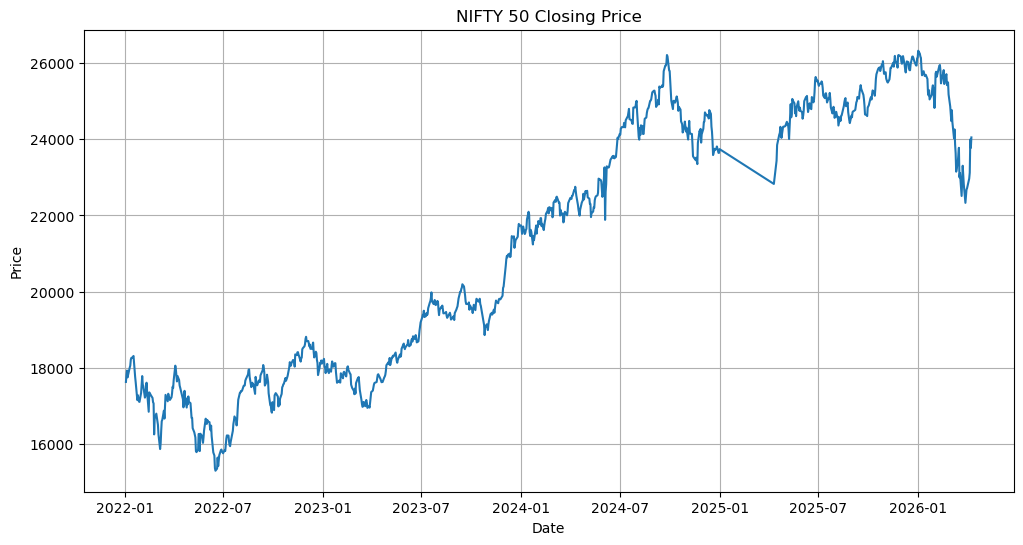

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("NIFTY 50 Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

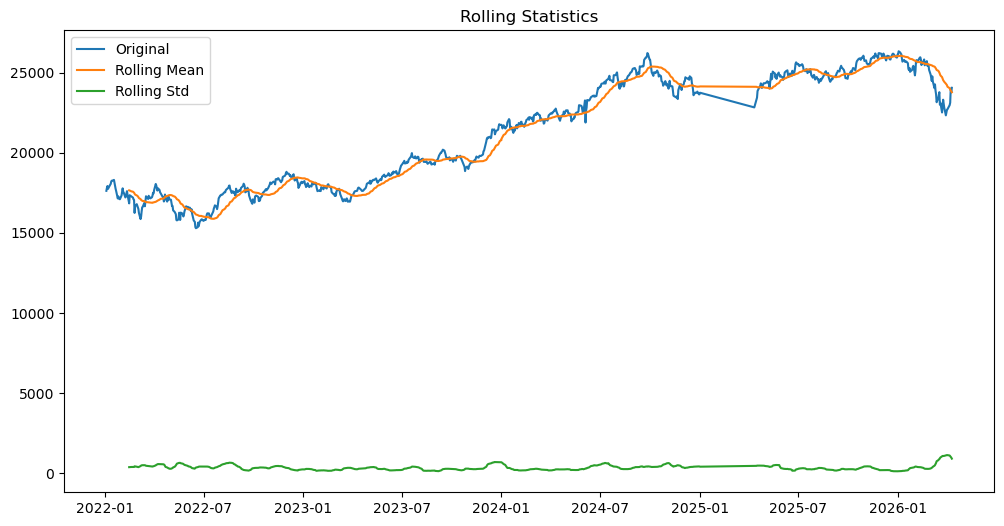

In [6]:
rolling_mean = df['Close'].rolling(window=30).mean()
rolling_std = df['Close'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

In [7]:
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.8998745698133152
p-value: 0.7880137208261233


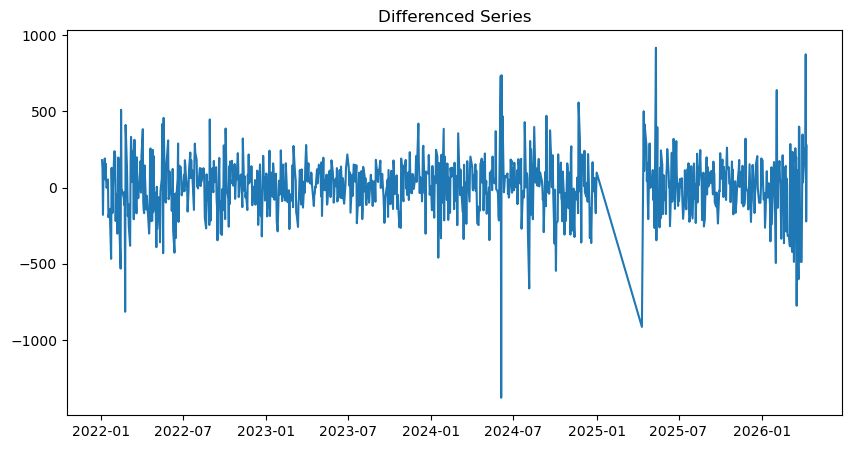

In [8]:
df_diff = df['Close'].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(df_diff)
plt.title("Differenced Series")
plt.show()

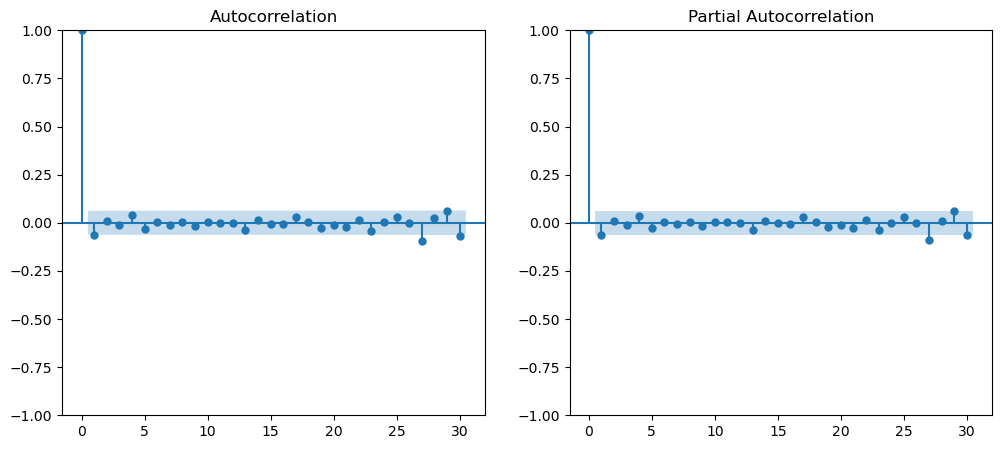

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plot_acf(df_diff, ax=plt.gca())

plt.subplot(122)
plot_pacf(df_diff, ax=plt.gca())

plt.show()

In [10]:
train = df[:int(len(df)*0.8)]
test = df[int(len(df)*0.8):]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 792
Test size: 199


In [11]:
model = ARIMA(train['Close'], order=(5,1,5))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  792
Model:                 ARIMA(5, 1, 5)   Log Likelihood               -5225.435
Date:                Sat, 11 Apr 2026   AIC                          10472.869
Time:                        21:56:11   BIC                          10524.275
Sample:                             0   HQIC                         10492.628
                                - 792                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2408      0.392     -0.613      0.540      -1.010       0.528
ar.L2          0.0833      0.171      0.487      0.626      -0.252       0.419
ar.L3         -0.1141      0.170     -0.669      0.5

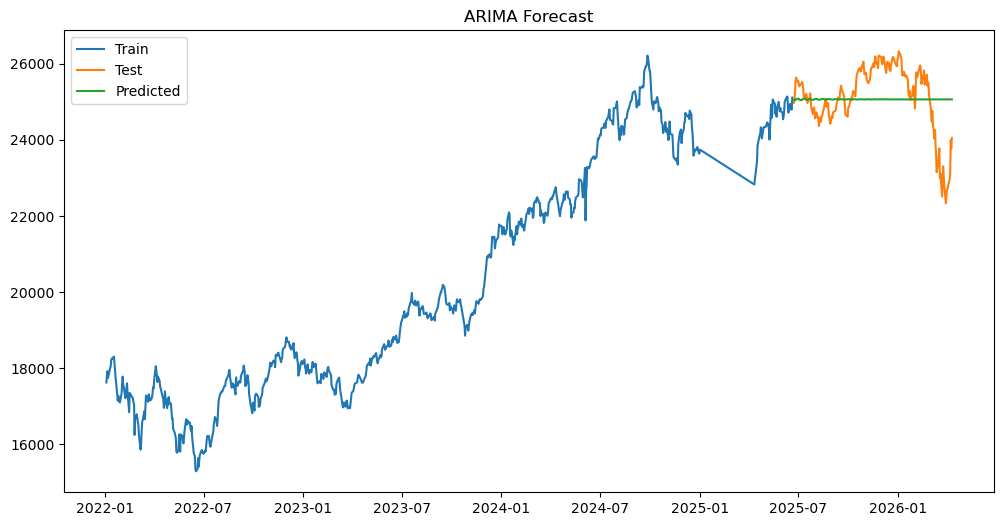

In [12]:
pred = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train['Close'], label='Train')
plt.plot(test['Close'], label='Test')
plt.plot(test.index, pred, label='Predicted')

plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [13]:
rmse = np.sqrt(mean_squared_error(test['Close'], pred))
mae = mean_absolute_error(test['Close'], pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 838.9807036310953
MAE: 647.7982073056905


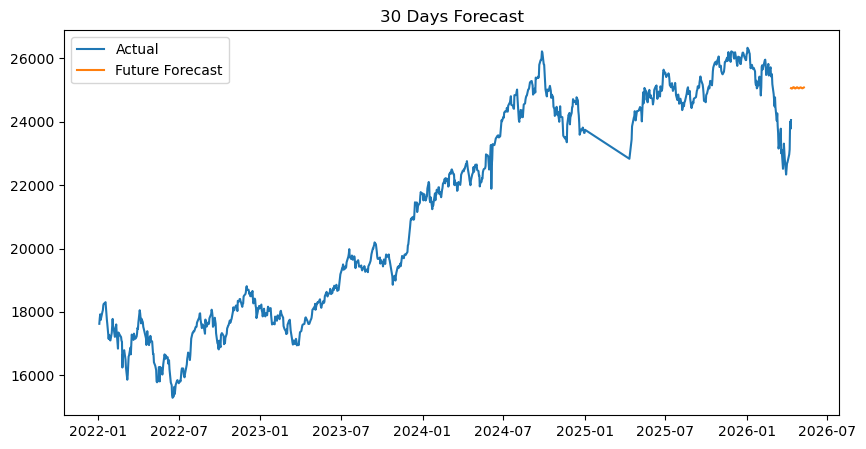

In [14]:
future_forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Actual')
plt.plot(pd.date_range(df.index[-1], periods=30, freq='D'), future_forecast, label='Future Forecast')

plt.legend()
plt.title("30 Days Forecast")
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor

df_rf = df.copy()

df_rf['lag1'] = df_rf['Close'].shift(1)
df_rf['lag2'] = df_rf['Close'].shift(2)

df_rf.dropna(inplace=True)

X = df_rf[['lag1', 'lag2']]
y = df_rf['Close']

split = int(len(df_rf)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred_rf = model.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

RF RMSE: 230.55768857351953


In [17]:
df.to_csv('C:\\Users\\Taufique\\Downloads\\clean_nifty50.csv',encoding='unicode_escape')